In [178]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [179]:
pd.set_option('display.max_columns',None)
df=pd.read_csv('gurgaon_properties_cleaned_v2.csv')

In [180]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,bptp terra,sector 37,1.67,7622.0,2191.0,Super Built up area 2191(203.55 sq.m.)Built Up...,4,4,3,11.0,West,Relatively New,2191.0,2091.0,1991.0,0,0,0,0,0,1,149
1,house,rattan garden,sector 7,1.30,13499.0,963.0,Built Up area: 963 (89.47 sq.m.),5,3,2,3.0,NaN,Old Property,NaN,963.0,NaN,0,0,0,0,0,0,0
2,house,independent,sector 14,4.15,18444.0,2250.0,Plot area 250(209.03 sq.m.),5,4,2,2.0,North-West,Old Property,NaN,2250.0,NaN,0,0,0,0,0,1,51
3,flat,apartment,sector 92,0.75,4687.0,1600.2,Carpet area: 1600 (148.64 sq.m.),3,4,3,2.0,East,Moderately Old,NaN,NaN,1600.0,0,0,0,0,0,0,113
4,house,independent,sector 4,50.00,10482.0,47701.0,Built Up area: 53 (44.31 sq.m.),5,3,0,1.0,NaN,Undefined,NaN,53.0,NaN,0,0,0,0,0,0,0


# Price

<Axes: xlabel='price', ylabel='Count'>

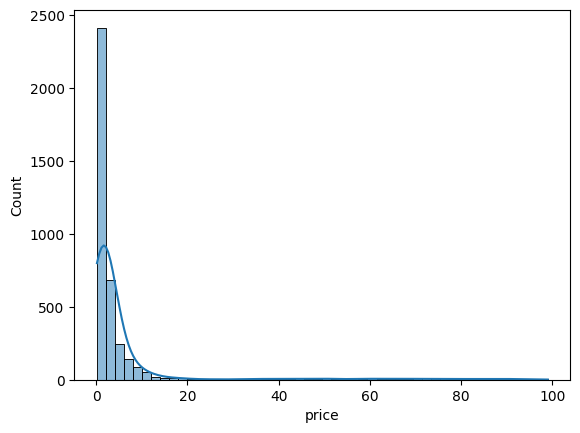

In [181]:
sns.histplot(df['price'],kde=True,bins=50)

<Axes: xlabel='price'>

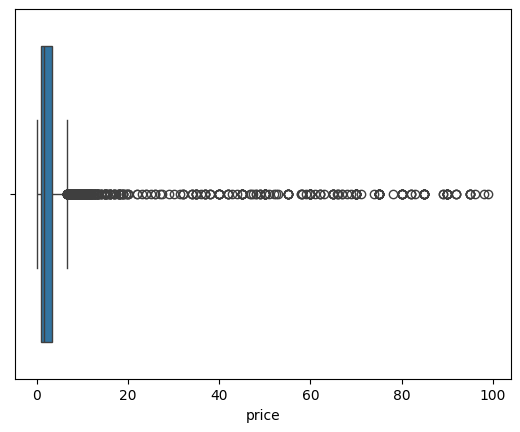

In [182]:
sns.boxplot(x=df['price'])

In [183]:
df['price'].describe()

count    3877.000000
mean        5.436807
std        13.677410
min         0.160000
25%         1.020000
50%         1.650000
75%         3.300000
max        99.000000
Name: price, dtype: float64

In [184]:
# outlier dataset
Q1=df['price'].describe()['25%']
Q3=df['price'].describe()['75%']
IQR=Q3-Q1
IQR

np.float64(2.28)

In [185]:
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outlier_df=df[(df['price']<lower_bound) | (df['price']>upper_bound)]

In [186]:
outlier_df

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
4,house,independent,sector 4,50.00,10482.0,47701.0,Built Up area: 53 (44.31 sq.m.),5,3,0,1.0,NaN,Undefined,NaN,53.00,NaN,0,0,0,0,0,0,0
9,house,independent,sector 4,67.00,88157.0,7600.0,Plot area 76(7.06 sq.m.),3,3,2,2.0,South,Relatively New,NaN,76.00,NaN,0,0,0,0,1,0,7
10,house,independent,sector 50,7.00,23333.0,3000.0,Plot area 2400(222.97 sq.m.)Built Up area: 340...,4,4,2,3.0,North-East,Old Property,NaN,3400.00,3000.0,0,1,0,0,0,0,118
15,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.00,NaN,0,1,0,0,0,1,31
17,house,independent,sector 43,15.50,28233.0,5490.0,Plot area 610(510.04 sq.m.),5,6,3,3.0,East,Moderately Old,NaN,5490.00,NaN,1,1,1,1,0,0,76
26,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,3,3,2,2.0,West,Moderately Old,NaN,241.00,240.0,0,1,0,0,0,1,66
46,house,independent,sector 13,50.00,90909.0,5500.0,Plot area 55(5.11 sq.m.),12,4,3,4.0,NaN,Old Property,NaN,55.00,NaN,0,0,0,0,0,0,15
55,house,independent,sector 12,90.00,13333.0,67502.0,Built Up area: 675 (62.71 sq.m.),4,4,0,2.0,NaN,Undefined,NaN,675.00,NaN,0,0,0,0,0,0,0
57,house,independent,sector 56,11.50,42032.0,2736.0,Plot area 304(254.18 sq.m.),12,13,3+,4.0,West,Relatively New,NaN,2736.00,NaN,1,1,0,1,0,1,49
64,house,independent,sector 25,13.50,37313.0,3618.0,Plot area 402(336.12 sq.m.),5,6,3+,4.0,North-East,Old Property,NaN,3618.00,NaN,0,0,0,0,1,1,79


In [187]:
outlier_df['price'].describe()

count    486.000000
mean      30.308498
std       27.806680
min        6.750000
25%        8.625000
50%       13.350000
75%       50.000000
max       99.000000
Name: price, dtype: float64

In [188]:
outlier_df.to_csv('outlierdf_price.csv', index=False, encoding='utf-8')

**Observation**
+ mostly outliers(right skweed data) are bcz of area calucation error bcz of wrong area calculation it give extreme outlier values
+ we need to calculate it again
+ but some price are genuinely high they have no error
+ price has outlier bcz here we calculate some price based on area and price_per_sqft that might give wrong price so here the data error
  

# Price_per_sqft


In [189]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,bptp terra,sector 37,1.67,7622.0,2191.0,Super Built up area 2191(203.55 sq.m.)Built Up...,4,4,3,11.0,West,Relatively New,2191.0,2091.0,1991.0,0,0,0,0,0,1,149
1,house,rattan garden,sector 7,1.30,13499.0,963.0,Built Up area: 963 (89.47 sq.m.),5,3,2,3.0,NaN,Old Property,NaN,963.0,NaN,0,0,0,0,0,0,0
2,house,independent,sector 14,4.15,18444.0,2250.0,Plot area 250(209.03 sq.m.),5,4,2,2.0,North-West,Old Property,NaN,2250.0,NaN,0,0,0,0,0,1,51
3,flat,apartment,sector 92,0.75,4687.0,1600.2,Carpet area: 1600 (148.64 sq.m.),3,4,3,2.0,East,Moderately Old,NaN,NaN,1600.0,0,0,0,0,0,0,113
4,house,independent,sector 4,50.00,10482.0,47701.0,Built Up area: 53 (44.31 sq.m.),5,3,0,1.0,NaN,Undefined,NaN,53.0,NaN,0,0,0,0,0,0,0


<Axes: xlabel='price_per_sqft', ylabel='Count'>

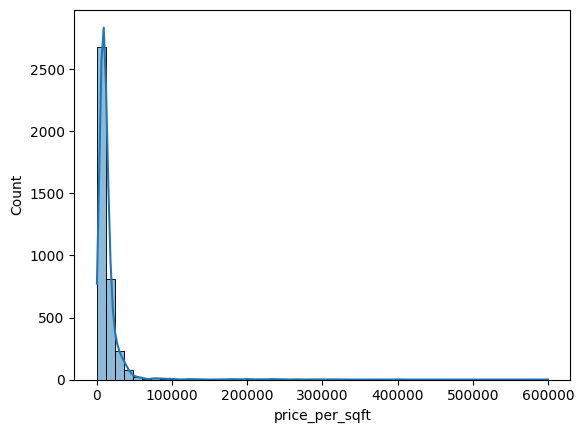

In [190]:
sns.histplot(df['price_per_sqft'],kde=True,bins=50)

<Axes: xlabel='price_per_sqft'>

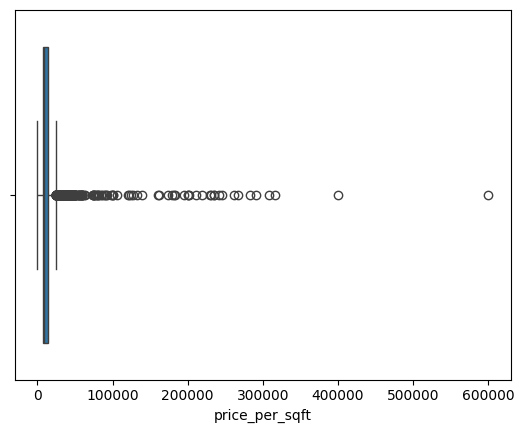

In [191]:
sns.boxplot(x=df['price_per_sqft'])

In [192]:
Q1=df['price_per_sqft'].describe()['25%']
Q3=df['price_per_sqft'].describe()['75%']
IQR=Q3-Q1
print(IQR)
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outlier_df=df[(df['price_per_sqft']<lower_bound)|(df['price_per_sqft']>upper_bound)]

6939.0


In [193]:
outlier_df['price_per_sqft'].describe() 

count       381.000000
mean      52834.173228
std       60291.318755
min       24170.000000
25%       27778.000000
50%       33333.000000
75%       42222.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

In [194]:
outlier_df['property_type'].value_counts()

property_type
house    348
flat      33
Name: count, dtype: int64

In [195]:
outlier_df[outlier_df['area']<1000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
53,house,independent,sector 43,1.90,35185.0,540.0,Plot area 60(50.17 sq.m.)Built Up area: 60 sq....,3,3,3+,3.0,NaN,Old Property,NaN,60.0,NaN,0,0,0,0,0,2,0
128,flat,breez global hill view,sector 48,2.60,46917.0,554.2,Carpet area: 554.16 (51.48 sq.m.),2,2,2,6.0,NaN,New Property,NaN,NaN,554.125572,0,0,0,0,0,0,42
145,house,eros rosewood city,sector 49,1.60,31481.0,508.0,Plot area 60(50.17 sq.m.),4,4,3,4.0,East,New Property,NaN,60.0,NaN,0,0,0,0,0,1,27
270,house,independent,sector 17,3.50,218750.0,160.0,Built Up area: 160 (14.86 sq.m.),6,6,3+,3.0,North-West,Undefined,NaN,160.0,NaN,0,0,0,0,0,0,0
319,house,independent,sector 13,9.00,100000.0,900.0,Plot area 900(83.61 sq.m.),10,5,3+,4.0,NaN,Old Property,NaN,900.0,NaN,0,0,0,0,0,0,0
520,house,vatika india next,sector 82,7.00,194444.0,360.0,Plot area 360(33.45 sq.m.)Built Up area: 3900 ...,4,4,3+,3.0,North-East,Relatively New,NaN,3900.0,3743.000000,0,1,0,0,0,2,105
556,house,ansal,sector 43,1.85,308333.0,60.0,Plot area 60(5.57 sq.m.),8,8,3+,5.0,North-West,Relatively New,NaN,60.0,NaN,0,0,0,0,0,0,53
588,house,dlf city plots phase 3,sector 24,1.44,26667.0,540.0,Plot area 60(50.17 sq.m.),4,2,2,1.0,NaN,Old Property,NaN,540.0,NaN,0,0,0,0,0,0,8
619,house,independent,sector 7,1.00,79365.0,126.0,Plot area 126(11.71 sq.m.),2,2,0,0.0,NaN,Old Property,NaN,126.0,NaN,1,0,0,0,0,0,7
655,house,dlf city phase 1,sector 26,3.25,33129.0,981.0,Plot area 109(91.14 sq.m.),3,3,3,2.0,West,Old Property,NaN,981.0,NaN,1,0,0,0,0,0,79


In [196]:
outlier_df[outlier_df['area']<1000].index

Index([  53,  128,  145,  270,  319,  520,  556,  588,  619,  655,  714,  831,
        871,  904,  987, 1140, 1186, 1256, 1319, 1366, 1373, 1378, 1432, 1436,
       1484, 1592, 1654, 1660, 1672, 1690, 1802, 1817, 1854, 1940, 1962, 1971,
       2021, 2048, 2144, 2155, 2167, 2217, 2247, 2252, 2267, 2447, 2470, 2567,
       2593, 2643, 2688, 2713, 2812, 2860, 2876, 2950, 3110, 3118, 3221, 3354,
       3358, 3370, 3764, 3774, 3844, 3858],
      dtype='int64')

In [197]:
outlier_df['area']=outlier_df['area'].apply(lambda x:x*9 if x<1000 else x )

C:\Users\sarth\AppData\Local\Temp\ipykernel_6936\3029074520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlier_df['area']=outlier_df['area'].apply(lambda x:x*9 if x<1000 else x )


In [198]:
outlier_df[outlier_df['area']<1000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
556,house,ansal,sector 43,1.85,308333.0,540.0,Plot area 60(5.57 sq.m.),8,8,3+,5.0,North-West,Relatively New,NaN,60.0,NaN,0,0,0,0,0,0,53
831,flat,housing board colony,sector 51,0.30,41666.0,648.0,Carpet area: 72 (6.69 sq.m.),1,1,0,0.0,NaN,Moderately Old,NaN,NaN,72.0,0,0,0,0,0,0,15
2217,house,independent,sector 55,1.45,241666.0,540.0,Plot area 60(5.57 sq.m.),4,4,3+,4.0,East,Relatively New,NaN,60.0,NaN,0,0,1,0,0,0,70
3844,house,independent,sector 54,1.60,160000.0,900.0,Plot area 100(9.29 sq.m.),3,2,2,41.0,NaN,Relatively New,NaN,100.0,NaN,0,0,0,0,0,0,0


In [199]:
outlier_df.loc[[53,  128,  145,  270,  319,  520,  556,  588,  619,  655,  714,  831,
        871,  904,  987, 1140, 1186, 1256, 1319, 1366, 1373, 1378, 1432, 1436,
       1484, 1592, 1654, 1660, 1672, 1690, 1802, 1817, 1854, 1940, 1962, 1971,
       2021, 2048, 2144, 2155, 2167, 2217, 2247, 2252, 2267, 2447, 2470, 2567,
       2593, 2643, 2688, 2713, 2812, 2860, 2876, 2950, 3110, 3118, 3221, 3354,
       3358, 3370, 3764, 3774, 3844, 3858]]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
53,house,independent,sector 43,1.90,35185.0,4860.0,Plot area 60(50.17 sq.m.)Built Up area: 60 sq....,3,3,3+,3.0,NaN,Old Property,NaN,60.0,NaN,0,0,0,0,0,2,0
128,flat,breez global hill view,sector 48,2.60,46917.0,4987.8,Carpet area: 554.16 (51.48 sq.m.),2,2,2,6.0,NaN,New Property,NaN,NaN,554.125572,0,0,0,0,0,0,42
145,house,eros rosewood city,sector 49,1.60,31481.0,4572.0,Plot area 60(50.17 sq.m.),4,4,3,4.0,East,New Property,NaN,60.0,NaN,0,0,0,0,0,1,27
270,house,independent,sector 17,3.50,218750.0,1440.0,Built Up area: 160 (14.86 sq.m.),6,6,3+,3.0,North-West,Undefined,NaN,160.0,NaN,0,0,0,0,0,0,0
319,house,independent,sector 13,9.00,100000.0,8100.0,Plot area 900(83.61 sq.m.),10,5,3+,4.0,NaN,Old Property,NaN,900.0,NaN,0,0,0,0,0,0,0
520,house,vatika india next,sector 82,7.00,194444.0,3240.0,Plot area 360(33.45 sq.m.)Built Up area: 3900 ...,4,4,3+,3.0,North-East,Relatively New,NaN,3900.0,3743.000000,0,1,0,0,0,2,105
556,house,ansal,sector 43,1.85,308333.0,540.0,Plot area 60(5.57 sq.m.),8,8,3+,5.0,North-West,Relatively New,NaN,60.0,NaN,0,0,0,0,0,0,53
588,house,dlf city plots phase 3,sector 24,1.44,26667.0,4860.0,Plot area 60(50.17 sq.m.),4,2,2,1.0,NaN,Old Property,NaN,540.0,NaN,0,0,0,0,0,0,8
619,house,independent,sector 7,1.00,79365.0,1134.0,Plot area 126(11.71 sq.m.),2,2,0,0.0,NaN,Old Property,NaN,126.0,NaN,1,0,0,0,0,0,7
655,house,dlf city phase 1,sector 26,3.25,33129.0,8829.0,Plot area 109(91.14 sq.m.),3,3,3,2.0,West,Old Property,NaN,981.0,NaN,1,0,0,0,0,0,79


In [200]:
outlier_df['price_per_sqft']=round((outlier_df['price']*10000000)/outlier_df['area'],2)

C:\Users\sarth\AppData\Local\Temp\ipykernel_6936\2572529459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlier_df['price_per_sqft']=round((outlier_df['price']*10000000)/outlier_df['area'],2)


In [201]:
outlier_df['price_per_sqft'].describe() 
# old  Sstatistics:-->
# mean      52834.173228
# std       60291.318755
# min       24170.000000
# 25%       27778.000000
# 50%       33333.000000
# 75%       42222.000000
# max      600000.000000

count       381.000000
mean      33076.587507
std       18118.639053
min        2689.160000
25%       25925.930000
50%       30727.630000
75%       37627.270000
max      138888.890000
Name: price_per_sqft, dtype: float64

In [202]:
df.update(outlier_df)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

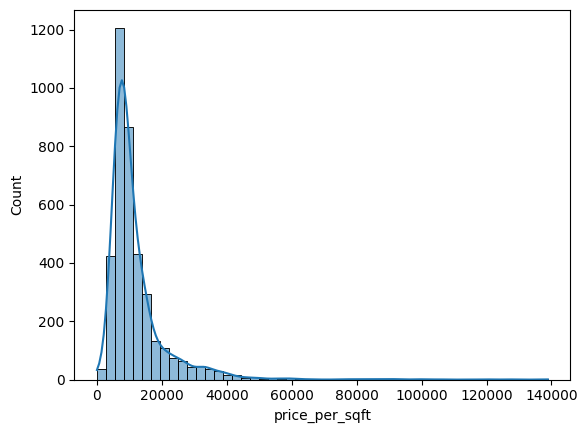

In [203]:
sns.histplot(df['price_per_sqft'],kde=True,bins=50)

<Axes: xlabel='price_per_sqft'>

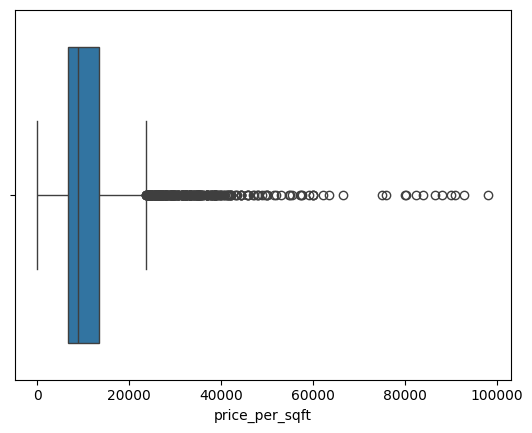

In [204]:
sns.boxplot(x=df[df['price_per_sqft']<100000]['price_per_sqft'])

In [205]:
df[(df['price_per_sqft']>50000)&(df['price']<10)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
134,house,cloudnine cottages,sector 48,5.5,55000.00,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,1.0,NaN,Moderately Old,NaN,1000.0,NaN,0,0,0,0,0,0,0
1103,house,project housing board colony,sector 31,8.0,63492.06,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,NaN,Undefined,NaN,140.0,NaN,0,0,0,0,0,0,0
2067,house,malibu towne,sector 47,8.5,53125.00,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,NaN,1600.0,NaN,0,0,0,0,0,1,99
2525,flat,unitech vistas,sector 70,9.0,57507.99,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,NaN,Undefined,NaN,1565.0,NaN,0,0,0,0,0,0,0


In [206]:
df=df[df['price_per_sqft']<=50000]

In [207]:
df.shape

(3844, 23)

<Axes: xlabel='price'>

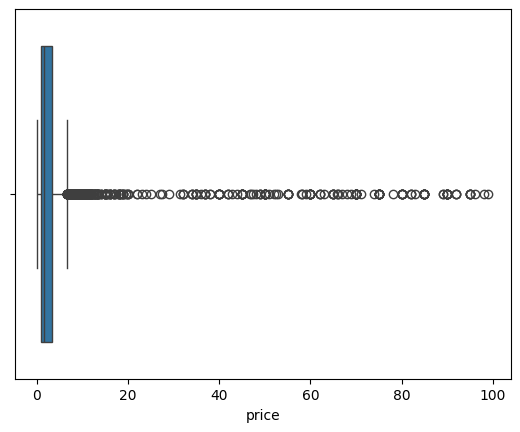

In [208]:
sns.boxplot(x=df['price'])

<Axes: xlabel='price_per_sqft'>

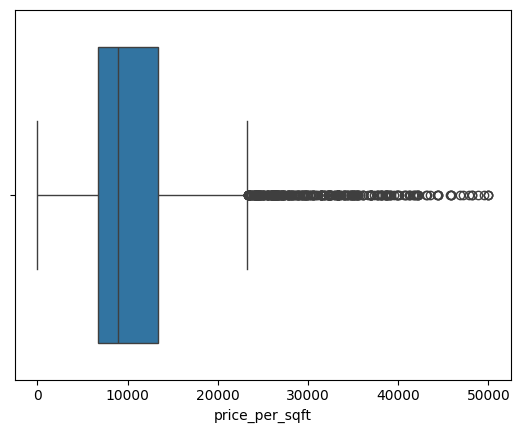

In [209]:
sns.boxplot(x=df['price_per_sqft'])

In [210]:
pd.set_option('display.max_rows', None)

In [211]:
df[df['price']>15]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
4,house,independent,sector 4,50.00,10482.00,47701.0,Built Up area: 53 (44.31 sq.m.),5,3,0,1.0,NaN,Undefined,NaN,53.0,NaN,0,0,0,0,0,0,0
15,house,luxury dlf city floors,sector 26,20.00,48887.80,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,1,31
17,house,independent,sector 43,15.50,28233.15,5490.0,Plot area 610(510.04 sq.m.),5,6,3,3.0,East,Moderately Old,NaN,5490.0,NaN,1,1,1,1,0,0,76
55,house,independent,sector 12,90.00,13333.00,67502.0,Built Up area: 675 (62.71 sq.m.),4,4,0,2.0,NaN,Undefined,NaN,675.0,NaN,0,0,0,0,0,0,0
81,house,independent,sector 8,59.00,10085.00,58503.0,Plot area 585(54.35 sq.m.),2,2,2,2.0,NaN,Moderately Old,NaN,585.0,NaN,0,0,0,0,1,0,7
87,house,independent,sector 21,45.00,8411.00,53501.0,Carpet area: 535 (49.7 sq.m.),3,2,1,1.0,NaN,Undefined,NaN,NaN,535.0,0,0,0,0,0,0,0
117,house,dlf city plots,sector 26,19.00,42054.01,4518.0,Plot area 502(419.74 sq.m.),6,6,3,2.0,East,Relatively New,NaN,4518.0,NaN,1,1,0,0,0,1,121
148,house,independent,sector 21,60.00,6173.00,97197.0,Plot area 108(90.3 sq.m.),8,3,2,3.0,NaN,Old Property,NaN,108.0,NaN,0,0,0,0,0,0,0
154,house,independent,sector 104,71.00,10142.00,70006.0,Plot area 700(65.03 sq.m.),4,2,1,2.0,NaN,New Property,NaN,700.0,NaN,0,0,0,0,0,0,0
168,house,independent,sector 6,66.00,10784.00,61202.0,Plot area 612(56.86 sq.m.),3,2,1,2.0,NaN,Old Property,NaN,612.0,NaN,0,0,0,0,0,0,36


In [212]:
df[df['price']>20].shape

(170, 23)

In [213]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,bptp terra,sector 37,1.67,7622.0,2191.0,Super Built up area 2191(203.55 sq.m.)Built Up...,4,4,3,11.0,West,Relatively New,2191.0,2091.0,1991.0,0,0,0,0,0,1,149
1,house,rattan garden,sector 7,1.30,13499.0,963.0,Built Up area: 963 (89.47 sq.m.),5,3,2,3.0,NaN,Old Property,NaN,963.0,NaN,0,0,0,0,0,0,0
2,house,independent,sector 14,4.15,18444.0,2250.0,Plot area 250(209.03 sq.m.),5,4,2,2.0,North-West,Old Property,NaN,2250.0,NaN,0,0,0,0,0,1,51
3,flat,apartment,sector 92,0.75,4687.0,1600.2,Carpet area: 1600 (148.64 sq.m.),3,4,3,2.0,East,Moderately Old,NaN,NaN,1600.0,0,0,0,0,0,0,113
4,house,independent,sector 4,50.00,10482.0,47701.0,Built Up area: 53 (44.31 sq.m.),5,3,0,1.0,NaN,Undefined,NaN,53.0,NaN,0,0,0,0,0,0,0


In [214]:
import re
import numpy as np

def extract_area_sqft(text, original_area):
    
    text = str(text)
    
    # find value inside bracket before 'sq.m'
    match = re.search(r'\(([\d\.]+)\s*sq\.m', text)
    
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639   # convert to sqft
    
    else:
        # if no sq.m found assume already sqft
        return original_area

df['final_area_sqft'] = df.apply(
    lambda row: extract_area_sqft(row['areaWithType'], row['area']),
    axis=1
)

# remove decimal if you want clean integer values
df['final_area_sqft'] = df['final_area_sqft'].round(0).astype(int)

In [215]:
outlier_df[~outlier_df['areaWithType'].str.contains('sq.m.')]
# it means all the outliers has area availble in sq meter

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score


In [216]:
df[~df['areaWithType'].str.contains('sq.m.')].shape
# 24 non outlier value has  such type of value these area are not given in sq mtr

(24, 24)

**plan of atack**
+ so now we compute the area based on the sq m metric for outliers -->
+ then calculate or validate the area for non outlier value -->

In [217]:
outlier_df['areaWithType'].value_counts()

areaWithType
Plot area 360(301.01 sq.m.)                                                                                               29
Plot area 300(250.84 sq.m.)                                                                                               17
Plot area 200(167.23 sq.m.)                                                                                               16
Plot area 500(418.06 sq.m.)                                                                                               13
Plot area 502(419.74 sq.m.)                                                                                               13
Plot area 150(125.42 sq.m.)                                                                                               11
Plot area 215(179.77 sq.m.)                                                                                               10
Plot area 270(225.75 sq.m.)                                                                                     

In [218]:
import re
import numpy as np

def smart_area_convert(text):
    
    if pd.isna(text):
        return np.nan
    
    text = text.lower()
    
    # extract first two numbers
    numbers = re.findall(r'\d+\.?\d*', text)
    
    if len(numbers) == 0:
        return np.nan
    
    main_value = float(numbers[0])
    
    if len(numbers) > 1:
        bracket_value = float(numbers[1])
        
        # convert bracket sq.m to sqft
        bracket_sqft = bracket_value * 10.7639
        
        # check if main value is yard
        if abs((main_value * 9) - bracket_sqft) < 5:
            return main_value * 9
        
        # check if main value is sqft
        if abs(main_value - bracket_sqft) < 5:
            return main_value
        
        # fallback
        return main_value
    
    return main_value


outlier_df['final_area_sqft'] = outlier_df['areaWithType'].apply(smart_area_convert)

In [219]:
outlier_df[['price','price_per_sqft','areaWithType','area','final_area_sqft']]

,price,price_per_sqft,areaWithType,area,final_area_sqft
9,67.00,88157.89,Plot area 76(7.06 sq.m.),7600.0,76.00
15,20.00,48887.80,Plot area 500(418.06 sq.m.),4091.0,4500.00
17,15.50,28233.15,Plot area 610(510.04 sq.m.),5490.0,5490.00
26,7.50,34722.22,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,2160.0,2160.00
46,50.00,90909.09,Plot area 55(5.11 sq.m.),5500.0,55.00
53,1.90,3909.47,Plot area 60(50.17 sq.m.)Built Up area: 60 sq....,4860.0,540.00
57,11.50,42032.16,Plot area 304(254.18 sq.m.),2736.0,2736.00
64,13.50,37313.43,Plot area 402(336.12 sq.m.),3618.0,3618.00
71,4.49,24455.34,Plot area 204(170.57 sq.m.),1836.0,1836.00
93,4.45,35177.87,Plot area 150(125.42 sq.m.),1265.0,1350.00


In [220]:
outlier_df['price_per_sqft'].describe()

count       381.000000
mean      33076.587507
std       18118.639053
min        2689.160000
25%       25925.930000
50%       30727.630000
75%       37627.270000
max      138888.890000
Name: price_per_sqft, dtype: float64